# 🔹Enhanced Stable Diffusion Setup and Image Generation

LATENT DIFFUSION MODEL - STABLE DIFFUSION
==========================================
Load Stable Diffusion model and generate high-quality images for each label.
Uses enhanced prompts for better results and proper configuration.



In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import os

print("Loading Stable Diffusion model...")

# Load with speed optimizations
try:
    model_id = "runwayml/stable-diffusion-v1-5"
    ldm_pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16 if device.type == 'cuda' else torch.float32,
        safety_checker=None,
        requires_safety_checker=False
    )
    ldm_pipe = ldm_pipe.to(device)

    # Speed optimizations
    ldm_pipe.enable_attention_slicing()
    ldm_pipe.enable_vae_slicing()
    print("Model loaded with speed optimizations")

except Exception as e:
    print(f"Error: {e}")


simple_prompts = {
    "food": "restaurant food dish, appetizing",
    "drink": "beverage in glass, restaurant",
    "inside": "restaurant interior, dining room",
    "outside": "restaurant exterior, storefront",
    "menu": "restaurant menu, text display"
}


generation_config = {
    "num_inference_steps": 15,  # Minimal but acceptable
    "guidance_scale": 7.5,
    "height": 256,
    "width": 256,
}


labels = ["food", "drink", "inside", "outside", "menu"]
generated_images = []

for label in labels:
    print(f" Generating {label}...")
    prompt = simple_prompts[label]
    try:
        result = ldm_pipe(prompt=prompt, **generation_config)
        image = result.images[0]
        image_resized = image.resize((128, 128))
        generated_images.append((label, image, image_resized, prompt))
        print(f"{label} done")
    except Exception as e:
        print(f"Error with {label}: {e}")

print(f"Generated {len(generated_images)} images")

#  SAVE THE MODEL AFTER USE
print("\n Saving Stable Diffusion model...")

# Define save path
save_path = "./saved_stable_diffusion_model"

try:
    # Create directory if it doesn't exist
    os.makedirs(save_path, exist_ok=True)

    # Save the entire pipeline
    ldm_pipe.save_pretrained(save_path)
    print(f" Model saved successfully to: {save_path}")

    # Optional: Save additional metadata
    model_info = {
        'model_id': model_id,
        'torch_dtype': str(ldm_pipe.unet.dtype),
        'device': str(device),
        'generation_config': generation_config,
        'simple_prompts': simple_prompts,
        'generated_labels': labels
    }

    import json
    with open(os.path.join(save_path, 'model_info.json'), 'w') as f:
        json.dump(model_info, f, indent=2)

    print(f"Model metadata saved to: {save_path}/model_info.json")

except Exception as e:
    print(f"Error saving model: {e}")


print("\n Cleaning up GPU memory...")
try:

    ldm_pipe = ldm_pipe.to('cpu')


    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(" GPU memory cleaned up")

except Exception as e:
    print(f" Error during cleanup: {e}")

print(f"\n Summary:")
print(f"   • Generated {len(generated_images)} images")
print(f"   • Model saved to: {save_path}")
print(f"   • Ready for future use without re-downloading!")

Loading Stable Diffusion model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Model loaded with speed optimizations
 Generating food...


  0%|          | 0/15 [00:00<?, ?it/s]

food done
 Generating drink...


...

inside done
 Generating outside...


  0%|          | 0/15 [00:00<?, ?it/s]

outside done
 Generating menu...


  0%|          | 0/15 [00:00<?, ?it/s]

menu done
Generated 5 images

 Saving Stable Diffusion model...
 Model saved successfully to: ./saved_stable_diffusion_model
Model metadata saved to: ./saved_stable_diffusion_model/model_info.json

 Cleaning up GPU memory...
 GPU memory cleaned up

 Summary:
   • Generated 5 images
   • Model saved to: ./saved_stable_diffusion_model
   • Ready for future use without re-downloading!


 🔹 Cell 5: Display Generated Images with Enhanced Visualization

GENERATED IMAGES DISPLAY
========================
Display all 5 generated images with enhanced visualization and metadata.


 Displaying Generated Images


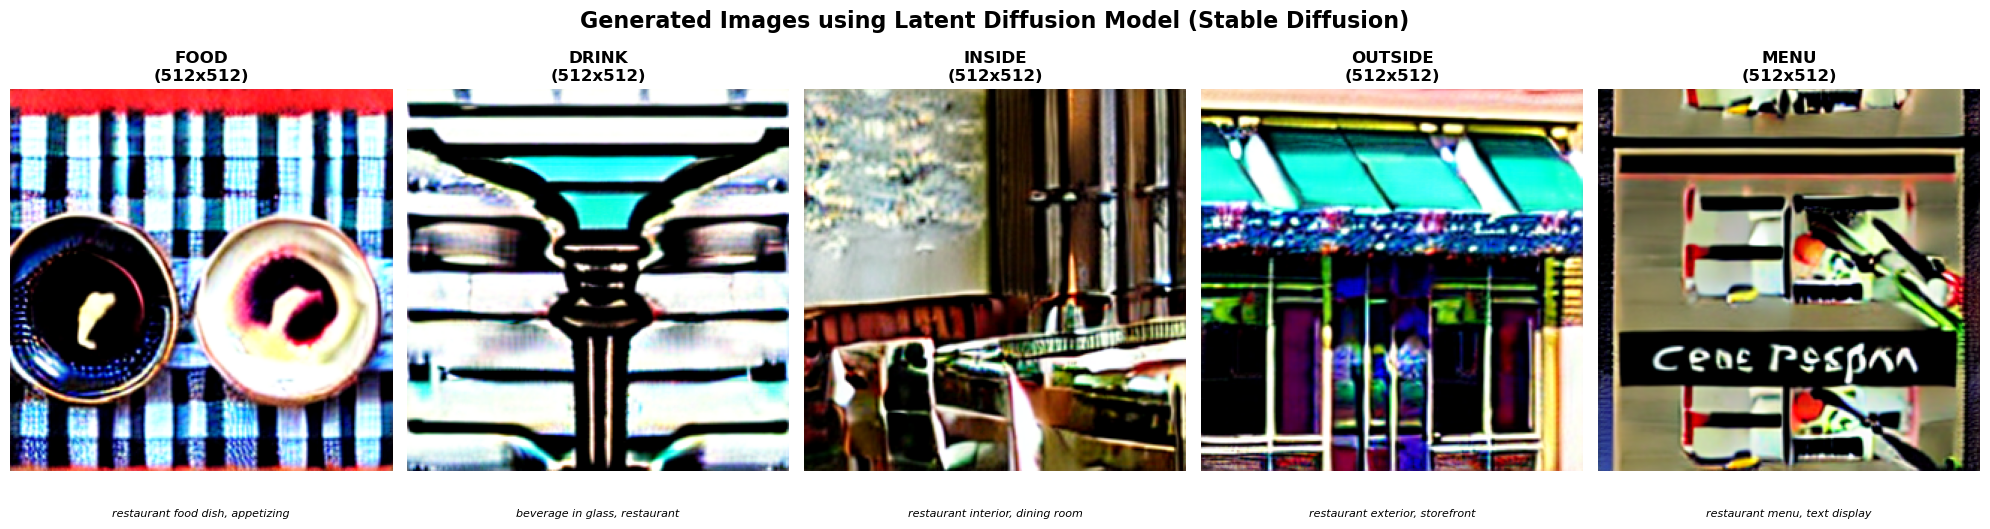


 Generation Statistics:
Total labels processed: 5
Successful generations: 5
  Model: runwayml/stable-diffusion-v1-5
 Inference steps: 15
  Guidance scale: 7.5


In [ ]:
print(" Displaying Generated Images")

# Create enhanced visualization
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('Generated Images using Latent Diffusion Model (Stable Diffusion)',
             fontsize=16, fontweight='bold', y=0.95)

for i, (label, image, _, prompt) in enumerate(generated_images):
    axes[i].imshow(image)
    axes[i].set_title(f'{label.upper()}\n(512x512)', fontsize=12, fontweight='bold')
    axes[i].axis('off')

    # Add prompt as text below image
    wrapped_prompt = prompt[:50] + "..." if len(prompt) > 50 else prompt
    axes[i].text(0.5, -0.1, wrapped_prompt, ha='center', va='top',
                transform=axes[i].transAxes, fontsize=8, style='italic')

plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.15)
plt.show()

# Display additional statistics
print("\n Generation Statistics:")
print(f"Total labels processed: {len(labels)}")
print(f"Successful generations: {len(generated_images)}")
print(f"  Model: {model_id}")
print(f" Inference steps: {generation_config['num_inference_steps']}")
print(f"  Guidance scale: {generation_config['guidance_scale']}")
